In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Environment is ready!")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

Environment is ready!
Pandas version: 2.3.3
NumPy version: 2.3.5
Scikit-learn version: 1.7.2


In [3]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [5]:
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

GPU available: False


In [6]:
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

GPU available: False


In [7]:
from pathlib import Path

# Location of our dataset
dataset_path = Path("../archive/chest_xray")

# Check whether the dataset exists
print("Dataset exists:", dataset_path.exists())

Dataset exists: False


In [8]:
from pathlib import Path

dataset_path = Path(r"E:\AI_project\archive\chest_xray")

print("Dataset exists:", dataset_path.exists())

Dataset exists: True


In [9]:
from pathlib import Path

dataset_path = Path(r"E:\AI_project\archive\chest_xray")

for folder in ["train", "test", "val"]:
    print(f"\n{folder.upper()} DATASET")
    
    for class_name in ["NORMAL", "PNEUMONIA"]:
        folder_path = dataset_path / folder / class_name
        
        # Count common image formats
        images = (
            list(folder_path.glob("*.jpeg")) +
            list(folder_path.glob("*.jpg")) +
            list(folder_path.glob("*.png"))
        )
        
        print(f"{class_name}: {len(images)} images")


TRAIN DATASET
NORMAL: 1341 images
PNEUMONIA: 3875 images

TEST DATASET
NORMAL: 234 images
PNEUMONIA: 390 images

VAL DATASET
NORMAL: 8 images
PNEUMONIA: 8 images


In [10]:
print("Training classes:", [folder.name for folder in (dataset_path / "train").iterdir()])
print("Testing classes:", [folder.name for folder in (dataset_path / "test").iterdir()])
print("Validation classes:", [folder.name for folder in (dataset_path / "val").iterdir()])

Training classes: ['NORMAL', 'PNEUMONIA']
Testing classes: ['NORMAL', 'PNEUMONIA']
Validation classes: ['NORMAL', 'PNEUMONIA']


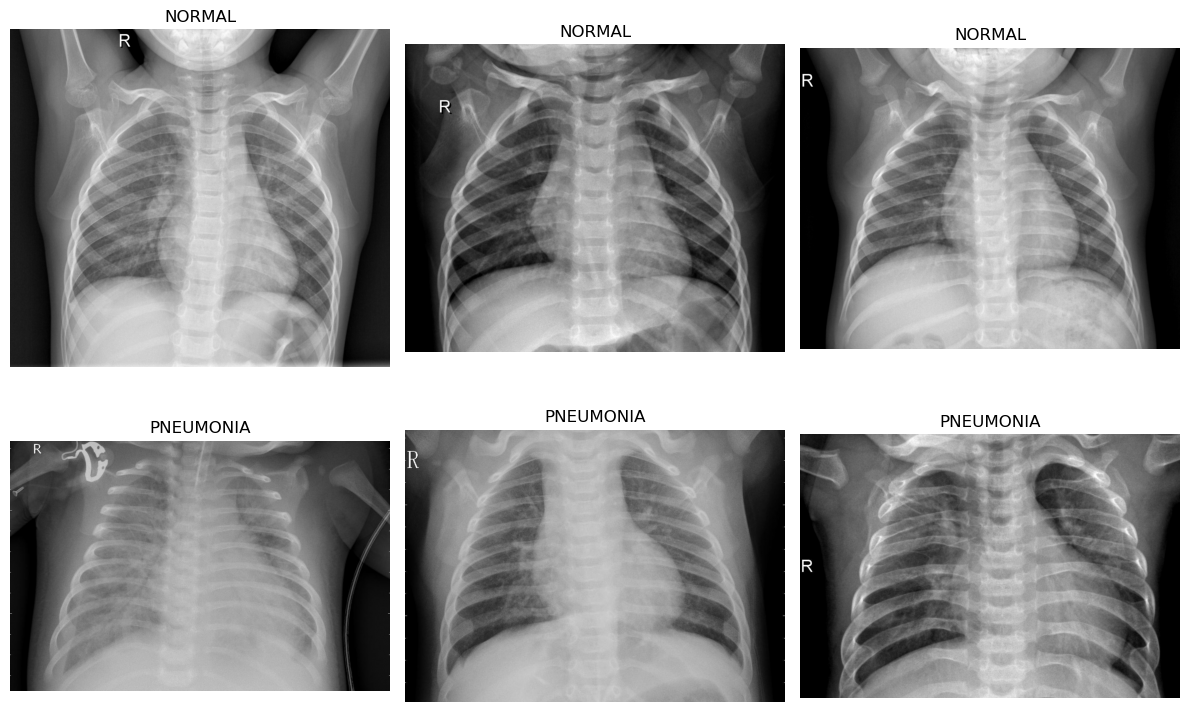

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

normal_images = list((dataset_path / "train" / "NORMAL").glob("*.jpeg"))
pneumonia_images = list((dataset_path / "train" / "PNEUMONIA").glob("*.jpeg"))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i in range(3):
    img = Image.open(normal_images[i])
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title("NORMAL")
    axes[0, i].axis("off")

for i in range(3):
    img = Image.open(pneumonia_images[i])
    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].set_title("PNEUMONIA")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [12]:
from PIL import Image
import numpy as np

# Check a few samples
sample_paths = list((dataset_path / "train" / "NORMAL").glob("*.jpeg"))[:5]

for path in sample_paths:
    img = Image.open(path)
    print(path.name, img.size, img.mode)


IM-0115-0001.jpeg (2090, 1858) L
IM-0117-0001.jpeg (1422, 1152) L
IM-0119-0001.jpeg (1810, 1434) L
IM-0122-0001.jpeg (1618, 1279) L
IM-0125-0001.jpeg (1600, 1125) L


In [13]:
import tensorflow as tf

img_height, img_width = 150, 150  # ✅ fixed

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path / "train",
    image_size=(img_height, img_width),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path / "val",
    image_size=(img_height, img_width),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path / "test",
    image_size=(img_height, img_width),
    batch_size=32
)

# Normalize
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [14]:
for images, labels in train_ds.take(1):
    print("Batch shape:", images.shape)
    print("Labels:", labels.numpy())


Batch shape: (32, 150, 150, 3)
Labels: [1 0 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 0 1 0 1 1 0 1 1 1 1 0]


In [20]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [22]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9988 - loss: 0.0050 - val_accuracy: 0.9375 - val_loss: 0.1724
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9954 - loss: 0.0117 - val_accuracy: 0.8125 - val_loss: 0.8218
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 162s 988ms/step - accuracy: 0.9933 - loss: 0.0176 - val_accuracy: 0.8750 - val_loss: 0.2222
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9919 - loss: 0.0279 - val_accuracy: 0.8125 - val_loss: 0.2416
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.9967 - loss: 0.0102 - val_accuracy: 0.9375 - val_loss: 0.0637
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.9988 - loss: 0.0055 - val_accuracy: 0.8750 - val_loss: 0.4910
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.9965 - loss: 0.0081 - val_accuracy: 0.9375 - val_loss: 0.3183
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9996 - loss: 0.0015 - val_a

In [23]:
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,485,445 (55.26 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,656,964 (36.84 MB)

In [24]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)


20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 428ms/step - accuracy: 0.7468 - loss: 4.7746
Test accuracy: 0.7467948794364929


Confusion Matrix:
[[ 78 156]
 [  2 388]]


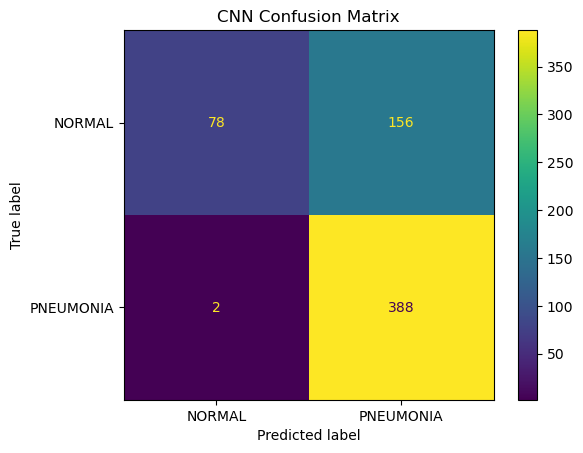

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions.ravel() >= 0.5).astype(int))

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()
plt.title("CNN Confusion Matrix")
plt.show()

In [26]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.97      0.33      0.50       234
   PNEUMONIA       0.71      0.99      0.83       390

    accuracy                           0.75       624
   macro avg       0.84      0.66      0.66       624
weighted avg       0.81      0.75      0.71       624



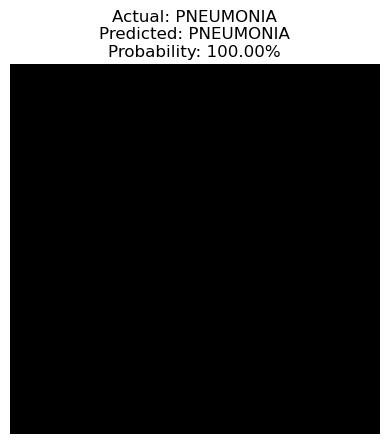

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of images from the test dataset
for images, labels in test_ds.take(1):
    image = images[0]
    true_label = labels[0].numpy()

    # Make prediction
    prediction = model.predict(np.expand_dims(image, axis=0), verbose=0)[0][0]

    # Convert probability to class
    if prediction >= 0.5:
        predicted_label = "PNEUMONIA"
    else:
        predicted_label = "NORMAL"

    # Display the image
    plt.imshow(image.numpy().astype("uint8"))
    plt.axis("off")
    plt.title(
        f"Actual: {'PNEUMONIA' if true_label == 1 else 'NORMAL'}\n"
        f"Predicted: {predicted_label}\n"
        f"Probability: {prediction:.2%}"
    )
    plt.show()

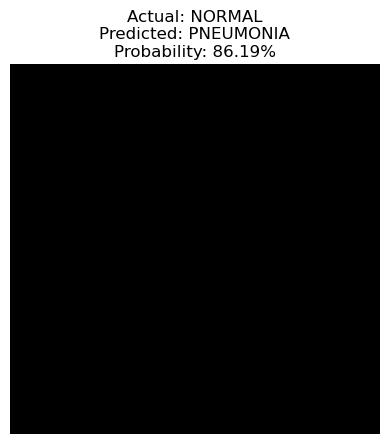

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of images from the test dataset
for images, labels in test_ds.take(1):
    image = images[0]
    true_label = labels[0].numpy()

    # Make prediction
    prediction = model.predict(np.expand_dims(image, axis=0), verbose=0)[0][0]

    # Convert probability to class
    if prediction >= 0.5:
        predicted_label = "PNEUMONIA"
    else:
        predicted_label = "NORMAL"

    # Display the image
    plt.imshow(image.numpy().astype("uint8"))
    plt.axis("off")
    plt.title(
        f"Actual: {'PNEUMONIA' if true_label == 1 else 'NORMAL'}\n"
        f"Predicted: {predicted_label}\n"
        f"Probability: {prediction:.2%}"
    )
    plt.show()

In [34]:
import os
image_path = r"E:\AI_project\new_images\xray1.jpeg"
print("Does the image exist?", os.path.exists(image_path))

Does the image exist? True


Prediction: PNEUMONIA
Confidence: 100.00%


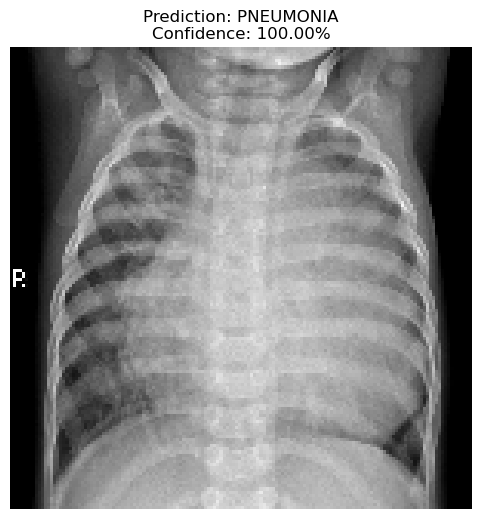

In [35]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

image_path = r"E:\AI_project\new_images\xray1.jpeg"

# Load the image
img = load_img(image_path, target_size=(150, 150))

# Convert image to numbers
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array, verbose=0)[0][0]

# Convert prediction to class
if prediction >= 0.5:
    predicted_label = "PNEUMONIA"
    confidence = prediction
else:
    predicted_label = "NORMAL"
    confidence = 1 - prediction

print("Prediction:", predicted_label)
print(f"Confidence: {confidence:.2%}")

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2%}")
plt.show()

In [36]:
# Save the model
model.save(r"E:\AI_project\chest_xray_model.h5")
print("Model saved successfully!")

Model saved successfully!
